In [ ]:
#Done
import pandas as pd
import numpy as np
from scipy.stats import skewnorm
import seaborn as sns
from efficient_apriori import apriori
import re

In [3]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
datas = pd.read_csv('PSCompPars_2025.06.12_09.54.16.csv', comment='#', low_memory=False)
data = pd.DataFrame(data=datas)
origdata = data.copy(deep = True)
#These two were labeled incorrectly on the dataframe
data.replace({ 'st_spectype': {'m3 V':'M V'} }, inplace = True)
data.replace({ 'st_spectype': {'sdBV':'B V'} }, inplace = True)

In [4]:
#assigns random temperature for each planet
def rand_temp(row):
    try:
        mean = row['pl_eqt'] + ((row['pl_eqterr1']+row['pl_eqterr2'])/2)
        sd = row['pl_eqt'] + row['pl_eqterr1'] - mean
        a = (3*(mean-row['pl_eqt']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_eqterr1'], size=1)[0]
    except:
        return row['pl_eqt']

#assigns random planet radius:  
def rand_prade(row):
    try:
        mean = row['pl_rade'] + ((row['pl_radeerr1']+row['pl_radeerr2'])/2)
        sd = row['pl_rade'] + row['pl_radeerr1'] - mean
        a = (3*(mean-row['pl_rade']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_radeerr1'], size=1)[0]
    except:
        return row['pl_rade']

#assigns random planet semimajor axis: 
def rand_majoraxis(row):
    try:
        mean = row['pl_orbsmax'] + ((row['pl_orbsmaxerr1']+row['pl_orbsmaxerr2'])/2)
        sd = row['pl_orbsmax'] + row['pl_orbsmaxerr1'] - mean
        a = (3*(mean-row['pl_orbsmax']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_orbsmaxerr1'], size=1)[0]
    except: 
        return row['pl_orbsmax']

#assigns random planet orbital period:
def rand_orbper(row):
    try:
        mean = row['pl_orbper'] + ((row['pl_orbpererr1']+row['pl_orbpererr2'])/2)
        sd = row['pl_orbper'] + row['pl_orbpererr1'] - mean
        a = (3*(mean-row['pl_orbper']))/sd
        return skewnorm.rvs(a, loc=mean, scale=row['pl_orbpererr1'], size=1)[0]
    except: 
        return row['pl_orbper']

#estimates the semimajor axis given a row of a data frame given stellar mass and orbital period: Kepler's 3rd law
#Only estimates the semimajor axis if the value is originally NaN
def estimate_orbsmax(row):
    if pd.isna(row['pl_orbsmax']):
        try: 
            return (((6.67e-11 * (row['st_mass'] * 1.989e30) * ((row['pl_orbper'] * 86400)**2)) / (4 * (np.pi**2)))**(1/3)) / 1.496e11
        except:
            return np.nan
    else:
        return row['pl_orbsmax']
        

#Sets the spectral type if it is already in the string for the spectype variable for each row.
#Otherwise, it is estimated based on equillibrium temperature.
def get_spectype(row):
    try: 
        return row['st_spectype'][0]
    except:
        if(row['st_teff']>=30000):
            return 'O'
        elif(row['st_teff']>=10000):
            return 'B'
        elif(row['st_teff']>=7500):
            return 'A'
        elif(row['st_teff']>=6000):
            return 'F'
        elif(row['st_teff']>=5200):
            return 'G'
        elif(row['st_teff']>=3700):
            return 'K'
        elif(row['st_teff']>=2400):
            return 'M'
        else:
            return row['st_spectype']

#Estimates the equillibrium temperature of a row given stellar luminosity, and semimajor axis
#Only estimates if there is a missing value for pl_eqt: Stefan-Boltzmann's law
def estimate_pl_eqt(row):
    if pd.isna(row['pl_eqt']):
        try:
            return (((10 ** row['st_lum']) * 3.827e26) / (16 * np.pi * 5.67e-8 * ((row['pl_orbsmax'] * 1.496e11) ** 2))) ** (1 / 4)
        except:
            return np.nan
    else:
        return row['pl_eqt']


#Grabs the last value of the string, usually the Luminosity Class of the star
#Otherwise, estimates whethoer or not the star is main sequence based on the luminosity of the star
def is_mainsequence(row):
    if(str(row['st_spectype'])[-1] == ('V') and str(row['st_spectype'])[-2:] != ('IV')):
        return 'True'
    else:
        try:
            if(str(row['spectype']).__contains__('M') and row['st_lum'] < -1.0969):
                return 'True'
            elif(str(row['spectype']).__contains__('K') and row['st_lum'] < -0.2218):
                return 'True'
            elif(str(row['spectype']).__contains__('G') and row['st_lum'] < 0.1761):
                return 'True'
            elif(str(row['spectype']).__contains__('F') and row['st_lum'] < 0.699):
                return 'True'
            elif(str(row['spectype']).__contains__('A') and row['st_lum'] < 1.3979):
                return 'True'
            elif(str(row['spectype']).__contains__('B') and row['st_lum'] < 4.477):
                return 'True'
            elif(str(row['spectype']).__contains__('O')):
                return 'True'
            else:
                return 'False'
        except:
            return 'False'   

#Gets the right hand and left hand side of the rule and puts it in an items list
pl_pattern = re.compile(r'(.+?)(\d)')
def parse_rule(rule_str):
    lhs, rhs = rule_str.split('->')
    lhs_items = [item.strip() for item in lhs.strip('{} ').split(',')]
    rhs = rhs.split("{")[1].split("}")[0]
    rhs_items = [item.strip() for item in rhs.strip('{} ').split(',')]
    return lhs_items, rhs_items

#Puts items in a system into a dictionary so that they are easy to compare, get counts for classifications
def get_plnum_dict(items):
    orbital_dict = {}
    for item in items:
        match = pl_pattern.match(item)
        if match:
            base_type, number = match.groups()
            number = int(number)
            orbital_dict.setdefault(base_type, set()).add(number)
    return orbital_dict

In [ ]:
#number of fake universes 
univnum = 100

1015


Text(0.5, 0, 'rule percent success per transactionset')

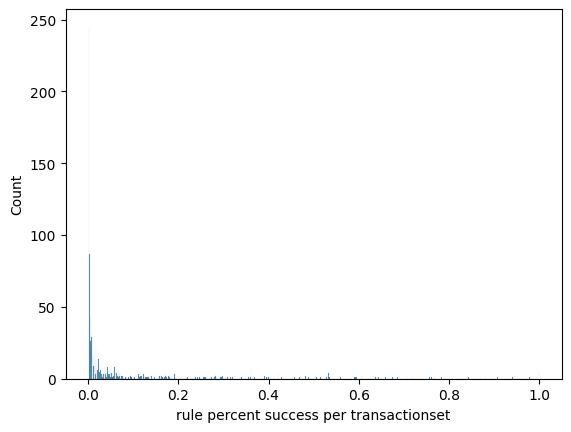

In [5]:
#all the rules and their proportion of prevalence in all universes
ruledict = dict()
# creates univnum universes with randomly asisgned variables
for i in range(univnum):
    # don't reuse the same set over and over again: start new
    data = origdata.copy(deep= True)

    #assigns random stellar temperature
    sortbyhost = data.groupby('hostname')
    for host, group in sortbyhost:
        count = 0
        number = 0
        for index, row in group.iterrows():
            try:
                if count == 0:
                    mean = row['st_teff'] + ((row['st_tefferr1'] + row['st_tefferr2']) / 2)
                    sd = row['st_teff'] + row['st_tefferr1'] - mean
                    a = (3 * (mean - row['st_teff'])) / sd
                    number = skewnorm.rvs(a, loc=mean, scale=sd, size=1)[0]
                    count += 1
                data.at[index, 'st_teff'] = number
            except Exception as e:
                data.at[index, 'st_teff'] = row['st_teff']

    #assigns random stellar luminosity
    for host, group in sortbyhost:
        count = 0
        number = 0
        for index, row in group.iterrows():
            try:
                if count == 0:
                    mean = row['st_lum'] + ((row['st_lumerr1'] + row['st_lumerr2']) / 2)
                    sd = row['st_lum'] + row['st_lumerr1'] - mean
                    a = (3 * (mean - row['st_lum'])) / sd
                    number = skewnorm.rvs(a, loc=mean, scale=sd, size=1)[0]
                    count += 1
                data.at[index, 'st_lum'] = number
            except Exception as e:
                data.at[index, 'st_lum'] = row['st_lum']
    #assigns random stellar mass
    for host, group in sortbyhost:
        count = 0
        number = 0
        for index, row in group.iterrows():
            try:
                if count == 0:
                    mean = row['st_mass'] + ((row['st_masserr1'] + row['st_masserr2']) / 2)
                    sd = row['st_mass'] + row['st_masserr1'] - mean
                    a = (3 * (mean - row['st_mass'])) / sd
                    number = skewnorm.rvs(a, loc=mean, scale=sd, size=1)[0]
                    count += 1
                data.at[index, 'st_mass'] = number
            except Exception as e:
                data.at[index, 'st_mass'] = row['st_mass']
    
    #applying all of the random variables
    data['pl_rade'] = data.apply(rand_prade, axis = 1)
    data['pl_orbper'] = data.apply(rand_orbper, axis = 1)
    data['pl_eqt'] = data.apply(rand_temp, axis = 1)
    data['pl_orbsmax'] = data.apply(rand_majoraxis, axis = 1)
    data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
    data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
    data['spectype'] = data.apply(get_spectype, axis = 1)
    data['isMS'] = data.apply(is_mainsequence, axis = 1)

    #Remove systems with more that one host star
    star = data.loc[data['sy_snum'] == 1]
    # Excluded planet systems that did not have any data on the variables of interest
    star = star.loc[star['pl_orbper'].isna() == False]
    star = star.loc[star['pl_rade'].isna() == False]
    star = star.loc[star['st_teff'].isna() == False]
    star = star.loc[star['pl_eqt'].isna() == False]
    star = star.loc[star['spectype'].isna() == False]
    #Grouping planets into their bins.
    star['pl_rad_bin'] = pd.cut(star['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
    star['pl_orb_bin'] = pd.cut(star['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
    star['pl_eqt_bin'] = pd.cut(star['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
    star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
    star['stars_class'] = star[['spectype', 'pl_class']].agg(" ".join, axis=1)
    #Creating a dataframe with only main sequence stars and their proper classificaiton
    onlyMS = star.loc[star['isMS'] == 'True']

    #only main sequence, planets
    '''test = {'type': onlyMS['pl_class'],'host':onlyMS['hostname']}'''

    #only main sequence, planets+ stars
    test = {'type': onlyMS['stars_class'],'host':onlyMS['hostname']}

    #all stars, planets
    '''test = {'type': star['pl_class'],'host':star['hostname']}'''

    #all stars, planets+ stars
    '''test = {'type': star['stars_class'],'host':star['hostname']}'''

    testing = pd.DataFrame(data=test)
    repeats = testing.groupby('host')

    #repeats = testingMSpl.groupby('host')
    modified_tuples = []
    for host, group in repeats:
        seen = {}
        new_types = []
        for t in group['type']:
            if t not in seen:
                seen[t] = 1
                new_types.append(f"{t}{seen[t]}")
            else:
                seen[t] += 1
                new_types.append(f"{t}{seen[t]}")
        modified_tuples.append(tuple(new_types))
    itemsetidk, repeatrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5)
    filtered_rules = []
    #goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
    for rule in repeatrules:
        rule_str = str(rule)
        lhs_items, rhs_items = parse_rule(rule_str)
        lhs_plnum = get_plnum_dict(lhs_items)
        rhs_plnum = get_plnum_dict(rhs_items)
        all_items = lhs_items + rhs_items
        all_plnum = get_plnum_dict(all_items)
        rule_valid = True
        for base_type, plnums in lhs_plnum.items():
            for num in plnums:
                if num > 1:
                    required = set(range(1, num))
                    if not required.issubset(plnums):
                        rule_valid = False
                        break
            if not rule_valid:
                break
        for base_type, plnum in rhs_plnum.items():
            if not rule_valid:
                break
            for items in plnum:
                if items > 1:
                    required = set(range(1, items))
                    if not required.issubset(all_plnum[base_type]):
                        rule_valid = False
                        break
        if rule_valid:
            filtered_rules.append(rule)
    for rule in filtered_rules:
        looper = 0
        for x in ruledict:
            if(rule == x):
                ruledict[x]+=1
                looper = 1
        if(looper == 0):
            ruledict[rule] = 1

#convert to a proportion
for rules in ruledict:
    ruledict[rules] = ruledict[rules]/univnum
#output the number of unique rules for all simulations
print(ruledict.__len__())
distributionpercents = pd.DataFrame({'values': list(ruledict.values())})
distribution = sns.histplot(data = distributionpercents, x = 'values', bins= univnum, binrange=[0,1])
distribution.set_xlabel('rule percent success per transactionset')

In [ ]:
critvalcount = []

#Outputs the rules that occur in at least 90% of the simulations.
for key in ruledict:
    if(ruledict[key]>=.9):
        critvalcount.append(key)
        print (f"{key}: {ruledict[key]}")
#counts number of rules that achieve over 90% in the simulations.
print(critvalcount.__len__())

{G Cold Gas Giant Long Orbital1, G Warm Mini-Neptune Medium-Short Orbital1} -> {G Warm Mini-Neptune Medium-Short Orbital2} (conf: 0.500, supp: 0.001, lift: 31.553, conv: 1.968): 1.0
{G Hot Mini-Neptune Short Orbital1, G Temperate Sub-Saturn Medium-Long Orbital1} -> {G Warm Sub-Saturn Medium-Short Orbital1} (conf: 1.000, supp: 0.001, lift: 32.593, conv: 969318948.078): 1.0
{G Warm Sub-Saturn Medium-Long Orbital1, G Warm Sub-Saturn Medium-Short Orbital1} -> {G Temperate Sub-Saturn Medium-Long Orbital1} (conf: 1.000, supp: 0.001, lift: 109.852, conv: 990896830.748): 1.0
{G Temperate Sub-Saturn Medium-Long Orbital1, G Warm Sub-Saturn Medium-Long Orbital1} -> {G Warm Sub-Saturn Medium-Short Orbital1} (conf: 0.667, supp: 0.001, lift: 21.729, conv: 2.908): 1.0
4


### Looking at the agreements between the simulations ran above and just using the median values.

In [ ]:
#Runs the universe with the median values
data = origdata.copy(deep= True)
#applying all of the non-random variables
data['pl_orbsmax'] = data.apply(estimate_orbsmax, axis=1)
data['pl_eqt'] = data.apply(estimate_pl_eqt, axis = 1)
data['spectype'] = data.apply(get_spectype, axis = 1)
data['isMS'] = data.apply(is_mainsequence, axis = 1)
#Remove systems with more that one host star
star = data.loc[data['sy_snum'] < 2]
# Excluded planet systems that did not have any data on the variables of interest
star = star.loc[star['pl_orbper'].isna() == False]
star = star.loc[star['pl_rade'].isna() == False]
star = star.loc[star['st_teff'].isna() == False]
star = star.loc[star['pl_eqt'].isna() == False]
star = star.loc[star['spectype'].isna() == False]
star['pl_rad_bin'] = pd.cut(star['pl_rade'], bins = [0, 1.7, 3.9, 9.4, 5000], labels = ['Terrestrial', 'Mini-Neptune', 'Sub-Saturn', 'Gas Giant'])
star['pl_orb_bin'] = pd.cut(star['pl_orbper'], bins = [0, 10, 100, 1000, 10000000000], labels = ['Short Orbital', 'Medium-Short Orbital', 'Medium-Long Orbital', 'Long Orbital'])
star['pl_eqt_bin'] = pd.cut(star['pl_eqt'], bins = [0, 200, 400, 1000, 10000000], labels = ['Cold', 'Temperate', 'Warm', 'Hot'])
star['pl_class'] = star[['pl_eqt_bin','pl_rad_bin', 'pl_orb_bin']].astype('str').agg(" ".join, axis=1)
star['stars_class'] = star[['spectype', 'pl_class']].agg(" ".join, axis=1)
#Creating a dataframe with only main sequence stars and their proper classificaiton
onlyMS = star.loc[star['isMS'] == 'True']

#originally 55 only MS and pl class
'''test = {'type': onlyMS['pl_class'],'host':onlyMS['hostname']}'''

#originally 92 only MS and pl+star class
test = {'type': onlyMS['stars_class'],'host':onlyMS['hostname']}

#originally 70 all stars and pl class
'''test = {'type': star['pl_class'],'host':star['hostname']}'''

#Originally 103 all stars and pl+st class
'''test = {'type': star['stars_class'],'host':star['hostname']}'''

testing = pd.DataFrame(data=test)
repeats = testing.groupby('host')

#Put into tuples by host star for the package
modified_tuples = []
for host, group in repeats:
    seen = {}
    new_types = []
    for t in group['type']:
        if t not in seen:
            seen[t] = 1
            new_types.append(f"{t}{seen[t]}")
        else:
            seen[t] += 1
            new_types.append(f"{t}{seen[t]}")
    modified_tuples.append(tuple(new_types))
print(modified_tuples.__len__())
origitemset, origrules = apriori(modified_tuples, min_support= 2/len(modified_tuples), min_confidence=.5)
filtered_rules = []
#goes through every rule created using the cheat method and removes rules whose left side does not have sequential orders of planets: ex. 3 without 2 or 1
for rule in origrules:
    rule_str = str(rule)
    lhs_items, rhs_items = parse_rule(rule_str)
    lhs_plnum = get_plnum_dict(lhs_items)
    rhs_plnum = get_plnum_dict(rhs_items)
    all_items = lhs_items + rhs_items
    all_plnum = get_plnum_dict(all_items)
    rule_valid = True
    for base_type, plnums in lhs_plnum.items():
        for num in plnums:
            if num > 1:
                required = set(range(1, num))
                if not required.issubset(plnums):
                    rule_valid = False
                    break
        if not rule_valid:
            break
    for base_type, plnum in rhs_plnum.items():
        if not rule_valid:
            break
        for items in plnum:
            if items > 1:
                required = set(range(1, items))
                if not required.issubset(all_plnum[base_type]):
                    rule_valid = False
                    break
    if rule_valid:
        filtered_rules.append(rule)


print('There are ' + str(filtered_rules.__len__())+ ' rules.')


NameError: name 'origdata' is not defined

A critical value of 0.0 had 92 agreements between the data with and without error.
A critical value of 0.001 had 92 agreements between the data with and without error.
A critical value of 0.002 had 92 agreements between the data with and without error.
A critical value of 0.003 had 92 agreements between the data with and without error.
A critical value of 0.004 had 92 agreements between the data with and without error.
A critical value of 0.005 had 92 agreements between the data with and without error.
A critical value of 0.006 had 92 agreements between the data with and without error.
A critical value of 0.007 had 92 agreements between the data with and without error.
A critical value of 0.008 had 92 agreements between the data with and without error.
A critical value of 0.009 had 92 agreements between the data with and without error.
A critical value of 0.01 had 92 agreements between the data with and without error.
A critical value of 0.011 had 92 agreements between the data with an

[Text(0.5, 0, 'threshold percentage'),
 Text(0, 0.5, 'number of rules in agreement between datasets')]

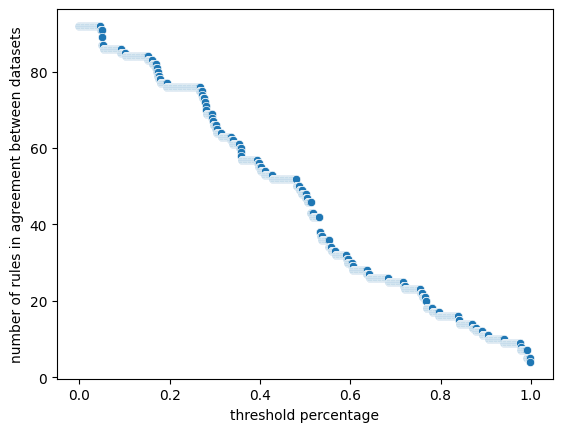

In [ ]:
# determines the number of matches between the simulation of n universes with randomly chosen characteristics and the median of the dataframe. Seportates for each threshold value on the simuation.
thresh = []
threshold = 0
agreements = []
while threshold<=1:
    critvalcount = []
    for key in ruledict:
        if(ruledict[key]>=threshold):
            critvalcount.append(key)
    agreement = 0    
    for orig in filtered_rules:
        for tot in critvalcount:
            if (tot == orig):
                agreement+=1
    thresh.append(threshold)
    agreements.append(agreement)
    print('A critical value of ' + str((round(univnum*threshold)/univnum)) + ' had ' + str(agreement) + ' agreements between the data with and without error.')
    threshold+=1/univnum
ohyeah = []
for key in ruledict:
        if(ruledict[key]>=1):
            for orig in filtered_rules:
                if (tot == orig):
                    ohyeah.append(orig)
print('There are ' + str(filtered_rules.__len__()) + ' rules without the error')
print('There are ' + str(ruledict.__len__()) + ' unique rules with the error across all simulations')
print(agreements)
print(ohyeah)
agreementplot = sns.scatterplot(x = thresh, y = agreements,)
agreementplot.set(xlabel = 'threshold percentage', ylabel = 'number of rules in agreement between datasets')